In [2]:
import polars as pl
import pandas as pd



In [3]:
filepath = "tracking_results/DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5"

In [4]:
tracking_df = pd.read_hdf(filepath)

out_df = tracking_df.copy()
scorer = out_df.columns.get_level_values("scorer")[0]

long_pdf = (
    tracking_df
    .stack(["scorer", "individuals", "bodyparts"])
    #.rename(["x","y"])
    .reset_index()
)
tracking_lf = pl.from_pandas(long_pdf).lazy().rename({'level_0':"frame"}).drop('scorer') #ograć rename wczytywaniem z hdf

/tmp/ipykernel_125608/1113783982.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(["scorer", "individuals", "bodyparts"])


In [ ]:
import numpy as np

disappear_expr = (pl.col('x').is_null() & pl.col('x').shift().over("individuals").is_not_null() )
reappear_expr = (pl.col('x').is_not_null() & pl.col('x').shift().over("individuals").is_null() )

individuals = [f"ind{i}" for i in range(1, 9)]

frame_grid = (
    tracking_lf
    .select("frame")
    .unique()
    .join(
        pl.LazyFrame({"individuals": individuals}),
        how="cross",
    )
)

tracking_lf = (
    tracking_lf
    .filter(pl.col("bodyparts") == "Dorsal2")
    .select("frame", "individuals", "bodyparts", "x", "y", "likelihood")
)

tracking_lf = (
    frame_grid
    .join(tracking_lf, on=["frame", "individuals"], how="left")
    .with_columns(
        bodyparts=pl.lit("Dorsal2")
    )
    .sort(["individuals", "frame"])
)

tracking_lf = tracking_lf.filter(
    pl.col('bodyparts') == "Dorsal2",#to decide, maybe centroid instead
).sort(
    ["individuals", "frame"]
).with_columns(
    (pl.col("x").is_between(460,830) & pl.col("y").is_between(300,970)).fill_null(False).alias("center")
).with_columns(
    [pl.when(
        ((pl.col("likelihood") >= 0.2)  & (pl.col('center').not_()))#magic numbers 
    ).then(
        pl.col(c)
    ).otherwise(None).alias(c)
    for c in ["x", "y"]]
).with_columns([
    pl.col(c).shift().over("individuals").alias(f"{c}_prev")
    for c in ["x", "y"]
]).with_columns(
    sum(pl.col(c).diff().over('individuals').pow(2) for c in ['x','y']).sqrt().alias('jump_dist'),
    reappear_expr.fill_null(False).alias('reappeared'),
    disappear_expr.fill_null(False).alias('disappeared')
).with_columns(
    ((pl.col("jump_dist") >= 20) | pl.col('reappeared') | pl.col('disappeared')).fill_null(False).alias("jump")
)
#.drop(pl.col("likelihood"))#.collect()

In [6]:
jump_events = (
    tracking_lf
    .filter(pl.col("jump"))
    .select(
        "frame",
        "individuals",
        "x",
        "y",
        "x_prev",
        "y_prev",
        "likelihood",
        "jump_dist",
        "center",
        "disappeared",
        "reappeared"
    )
    .sort(["frame", "individuals"])
)

jump_events.collect().to_pandas()

,frame,individuals,x,y,x_prev,y_prev,likelihood,jump_dist,center,disappeared,reappeared
0,0,ind5,210.343430,308.119843,NaN,NaN,0.923215,NaN,False,False,True
1,0,ind6,412.217102,117.987885,NaN,NaN,0.953052,NaN,False,False,True
2,0,ind7,1144.775879,258.562927,NaN,NaN,0.955455,NaN,False,False,True
3,0,ind8,934.484680,1131.885498,NaN,NaN,0.959999,NaN,False,False,True
4,86,ind1,402.994934,161.994583,NaN,NaN,0.754569,NaN,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
13260,107904,ind8,964.286194,1100.258545,NaN,NaN,0.969043,NaN,False,False,True
13261,107912,ind8,NaN,NaN,964.224854,1101.526001,NaN,NaN,False,True,False
13262,107924,ind8,996.015198,1064.841309,NaN,NaN,0.941606,NaN,False,False,True
13263,107946,ind6,962.003906,1102.610840,NaN,NaN,0.955340,NaN,False,False,True


In [7]:
jump_frames = (
    tracking_lf
    .filter(pl.col("jump"))
    .group_by("frame")
    .agg(
        pl.col("individuals").sort().alias("jumping_mice"),
        pl.len().alias("n_jumping_mice"),
    )
    .sort("frame")
)

jump_frames.collect().to_pandas()

,frame,jumping_mice,n_jumping_mice
0,0,"[ind5, ind6, ind7, ind8]",4
1,86,[ind1],1
2,90,[ind1],1
3,101,[ind2],1
4,103,[ind2],1
...,...,...,...
12193,107904,[ind8],1
12194,107912,[ind8],1
12195,107924,[ind8],1
12196,107946,[ind6],1


In [8]:
jump_pairs = (
    jump_events
    .join(jump_events, on="frame", suffix="_other")
    .filter(pl.col("individuals") < pl.col("individuals_other"))
.with_columns(
        a_now_to_b_prev=(
            (pl.col("x") - pl.col("x_prev_other")) ** 2
            + (pl.col("y") - pl.col("y_prev_other")) ** 2
        ).sqrt(),

        b_now_to_a_prev=(
            (pl.col("x_other") - pl.col("x_prev")) ** 2
            + (pl.col("y_other") - pl.col("y_prev")) ** 2
        ).sqrt(),

        a_self=(
            (pl.col("x") - pl.col("x_prev")) ** 2
            + (pl.col("y") - pl.col("y_prev")) ** 2
        ).sqrt(),

        b_self=(
            (pl.col("x_other") - pl.col("x_prev_other")) ** 2
            + (pl.col("y_other") - pl.col("y_prev_other")) ** 2
        ).sqrt(),
    )
    .with_columns(
        cross_total=pl.sum_horizontal(
            "a_now_to_b_prev",
            "b_now_to_a_prev",
            ignore_nulls=True,
        ),
        self_total=pl.sum_horizontal(
            "a_self",
            "b_self",
            ignore_nulls=True,
        ),
        n_cross_evidence=pl.sum_horizontal(
            pl.col("a_now_to_b_prev").is_not_null().cast(pl.Int8),
            pl.col("b_now_to_a_prev").is_not_null().cast(pl.Int8),
        ),
        n_self_evidence=pl.sum_horizontal(
            pl.col("a_self").is_not_null().cast(pl.Int8),
            pl.col("b_self").is_not_null().cast(pl.Int8),
        ),
    )
    .with_columns(
        possible_switch=(
            (pl.col("n_cross_evidence") > 0)
            & (pl.col("cross_total") < pl.col("self_total"))
        )
    )
    .filter(pl.col("possible_switch"))
    .sort(["frame", "cross_total"])
)

jump_pairs.collect(engine="streaming")

frame,individuals,x,y,x_prev,y_prev,likelihood,jump_dist,center,disappeared,reappeared,individuals_other,x_other,y_other,x_prev_other,y_prev_other,likelihood_other,jump_dist_other,center_other,disappeared_other,reappeared_other,a_now_to_b_prev,b_now_to_a_prev,a_self,b_self,cross_total,self_total,n_cross_evidence,n_self_evidence,possible_switch
i64,str,f64,f64,f64,f64,f64,f64,bool,bool,bool,str,f64,f64,f64,f64,f64,f64,bool,bool,bool,f64,f64,f64,f64,f64,f64,i8,i8,bool
2868,"""ind2""",933.70874,1136.850098,936.118896,1113.39917,0.750833,23.574454,false,false,false,"""ind4""",940.186218,1111.981079,null,null,0.824116,null,false,false,true,null,4.307446,23.574454,null,4.307446,23.574454,1,1,true
3174,"""ind1""",491.610168,293.049469,945.776001,1132.490845,0.727913,954.425705,false,false,false,"""ind2""",934.493774,1120.390503,null,null,0.82673,null,false,false,true,null,16.54409,954.425705,null,16.54409,954.425705,1,1,true
8381,"""ind4""",null,null,1015.610474,1019.452637,null,null,false,true,false,"""ind7""",1009.089417,1028.530151,1010.451843,1054.749512,0.771372,26.254734,false,false,false,null,11.177006,null,26.254734,11.177006,26.254734,1,1,true
16316,"""ind2""",997.10083,1071.325806,952.125305,1077.540649,0.897588,45.402887,false,false,false,"""ind5""",934.1828,1091.218384,null,null,0.830796,null,false,false,true,null,22.561336,45.402887,null,22.561336,45.402887,1,1,true
16317,"""ind2""",949.368103,1078.822021,997.10083,1071.325806,0.886673,48.317766,false,false,false,"""ind5""",null,null,934.1828,1091.218384,null,null,false,true,false,19.602633,null,48.317766,null,19.602633,48.317766,1,1,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
106983,"""ind2""",335.501953,183.329102,402.982269,870.309143,0.985003,690.286296,false,false,false,"""ind3""",null,null,283.478516,251.611771,0.635497,null,true,true,false,85.842652,null,690.286296,null,85.842652,690.286296,1,1,true
106985,"""ind2""",402.921722,870.592224,336.754913,184.434677,0.99633,689.340428,false,false,false,"""ind3""",283.668518,251.126633,null,null,0.842324,null,false,false,true,null,85.240731,689.340428,null,85.240731,689.340428,1,1,true
107123,"""ind3""",278.182587,254.807373,390.363586,174.37941,0.85618,138.033452,false,false,false,"""ind7""",330.554596,186.217499,null,null,0.944901,null,false,false,true,null,60.969301,138.033452,null,60.969301,138.033452,1,1,true


In [9]:
for coord in ["x", "y", "likelihood"]:
    wide_coord = tracking_lf.collect().pivot(
        index="frame",
        on="individuals",
        values=coord,
    )

    for individual in wide_coord.columns:
        out_df[(scorer, individual, "Dorsal2", coord)] = wide_coord[(individual)].to_numpy()

out_df.to_hdf(
    "DeepEcoHAB_20260501_211615_007DLC_DekrW18_the_future_of_EcohabNov22shuffle1_snapshot_best-260_el.h5",
    key="df_with_missing",
    mode="w",
)


In [10]:
tracking_lf.sort("frame").collect(engine="streaming").to_pandas()

,frame,individuals,bodyparts,x,y,likelihood,center,x_prev,y_prev,jump_dist,reappeared,disappeared,jump
0,0,ind1,Dorsal2,NaN,NaN,0.383084,False,NaN,NaN,NaN,False,False,False
1,0,ind2,Dorsal2,NaN,NaN,0.528054,False,NaN,NaN,NaN,False,False,False
2,0,ind3,Dorsal2,NaN,NaN,0.813487,True,NaN,NaN,NaN,False,False,False
3,0,ind4,Dorsal2,NaN,NaN,0.850423,True,NaN,NaN,NaN,False,False,False
4,0,ind5,Dorsal2,210.343430,308.119843,0.923215,False,NaN,NaN,NaN,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
863995,107999,ind4,Dorsal2,NaN,NaN,0.852806,True,NaN,NaN,NaN,False,False,False
863996,107999,ind5,Dorsal2,1108.964478,958.474060,0.914273,False,1108.336548,957.734436,0.970226,False,False,False
863997,107999,ind6,Dorsal2,NaN,NaN,0.523328,False,NaN,NaN,NaN,False,False,False
863998,107999,ind7,Dorsal2,415.452484,136.453751,0.975447,False,415.208679,136.593994,0.281263,False,False,False


In [11]:
antenna_df = pl.scan_csv(
    "tracking_results/DeepEcoHAB_20260501_211615_antenna_data.csv", 
    has_header=False,
    separator=";",
    new_columns=['antenna', 'tag', 'timestamp', 'datetime'],
    infer_schema_length=1000
    ).with_columns(
        pl.col('timestamp').str.to_integer(base=16)
    )

video_index = 7 #to extract from filename suffix
frames_per_video = 108000

antenna_df = antenna_df.with_columns(
    (pl.col('antenna')==10).cum_sum().alias('frame')
).filter(
    pl.col('frame').is_between(frames_per_video*video_index, frames_per_video*(video_index+1)-1)
).with_columns(
    (pl.col('frame')-pl.col('frame').first()).alias('frame')
)

In [12]:
antenna_df.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,10,01000000,13881021,2026-05-02T04:16:25.187506,0
1,10,01000000,13881025,2026-05-02T04:16:25.234955,1
2,10,01000000,13881028,2026-05-02T04:16:25.267095,2
3,10,01000000,13881031,2026-05-02T04:16:25.299101,3
4,10,01000000,13881035,2026-05-02T04:16:25.330489,4
...,...,...,...,...,...
115307,10,01000000,14241014,2026-05-02T05:16:25.269040,107995
115308,10,01000000,14241017,2026-05-02T05:16:25.300795,107996
115309,10,01000000,14241021,2026-05-02T05:16:25.341808,107997
115310,10,01000000,14241024,2026-05-02T05:16:25.371307,107998


In [13]:
antenna_df.filter(pl.col('tag')=='02000000').collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,1,02000000,14053249,2026-05-02T04:45:07.549451,51667


In [14]:
animal_detections = antenna_df.filter(
    pl.col("antenna") != 10#remove magic string
)

In [15]:
animal_detections.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725
...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451


In [16]:
animal_detections = animal_detections.with_columns(
    (
        pl.struct(["antenna", "tag"]).ne(pl.struct(["antenna", "tag"]).shift())
        | pl.col("frame").diff().gt(5)
    )
    .cum_sum()
    .cast(pl.Int16)
    .alias("run_id")
    .fill_null(0)
)
animal_detections.collect().to_pandas()
#group by run id of antenna and tag, with columns under antenna - in the future take the actual timestamp instead of frame

,antenna,tag,timestamp,datetime,frame,run_id
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0
1,5,F02AE61A,13883427,2026-05-02T04:16:49.269069,722,0
2,5,F02AE61A,13883431,2026-05-02T04:16:49.300830,723,0
3,5,F02AE61A,13883435,2026-05-02T04:16:49.348346,724,0
4,5,F02AE61A,13883439,2026-05-02T04:16:49.380227,725,0
...,...,...,...,...,...,...
7307,1,F02AE61A,14235857,2026-05-02T05:15:33.706488,106448,1459
7308,1,F02AE61A,14235861,2026-05-02T05:15:33.737894,106449,1459
7309,1,F02AE61A,14235865,2026-05-02T05:15:33.785172,106450,1459
7310,1,F02AE61A,14235869,2026-05-02T05:15:33.826882,106451,1459


In [17]:
antenna_with_coords = animal_detections.join(
    tracking_lf,
    on = 'frame',
    how = 'left'
)

In [18]:
antenna_with_coords = antenna_with_coords.filter((pl.col('tag') != '02000000') & (pl.col('tag') != '02000060')) #maybe use sanitation for that

In [19]:
antenna_with_coords.collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y,likelihood,center,x_prev,y_prev,jump_dist,reappeared,disappeared,jump
0,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind1,Dorsal2,1044.807983,744.289185,0.955294,False,1045.111816,741.696411,2.610515,False,False,False
1,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind2,Dorsal2,NaN,NaN,0.537632,True,NaN,NaN,NaN,False,False,False
2,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind3,Dorsal2,NaN,NaN,0.820318,True,NaN,NaN,NaN,False,False,False
3,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind4,Dorsal2,NaN,NaN,0.716963,True,NaN,NaN,NaN,False,False,False
4,5,F02AE61A,13883423,2026-05-02T04:16:49.228317,721,0,ind5,Dorsal2,201.814240,310.670593,0.924400,False,201.949646,310.428070,0.277763,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58475,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind4,Dorsal2,NaN,NaN,0.822526,True,NaN,NaN,NaN,False,False,False
58476,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind5,Dorsal2,1131.467163,946.468811,0.934604,False,1131.345947,946.324524,0.188446,False,False,False
58477,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind6,Dorsal2,389.522766,170.759018,0.946226,False,390.597717,172.941864,2.433174,False,False,False
58478,1,F02AE61A,14235873,2026-05-02T05:15:33.870102,106453,1459,ind7,Dorsal2,170.023682,366.717133,0.972335,False,171.993942,364.185730,3.207791,False,False,False


In [20]:
antenna_with_coords.group_by(
    ['run_id', 'antenna', 'tag', 'individuals']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect().to_pandas()

,run_id,antenna,tag,individuals,x,y
0,1045,1,0265E61A,ind6,966.790232,1111.351908
1,102,5,0265E61A,ind3,NaN,NaN
2,1107,6,EE1CEC1A,ind7,838.019953,1018.022081
3,1313,9,12F5FF19,ind2,NaN,NaN
4,167,8,F02AE61A,ind4,NaN,NaN
...,...,...,...,...,...,...
11659,1236,5,6D68A819,ind2,NaN,NaN
11660,1431,4,D5969C1A,ind5,NaN,NaN
11661,29,0,EE1CEC1A,ind1,156.325386,985.200104
11662,138,9,EE1CEC1A,ind7,1018.020721,996.894104


In [21]:
tst = antenna_with_coords.group_by(
    ['antenna']
).agg(
    pl.col("x").mean(),
    pl.col("y").mean(),
).collect()

In [22]:
import numpy as np
img = np.zeros([1280, 1280])

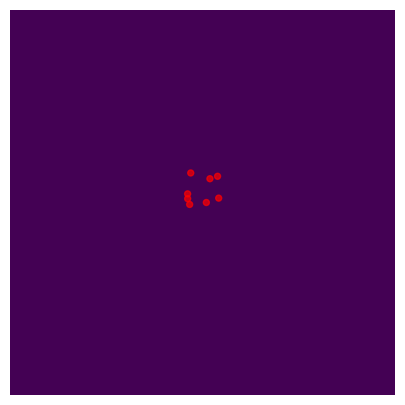

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.axis('off')

for x in tst.to_numpy():
    circle = Circle((x[1], x[2]), 10, color='red', fill=True, alpha=0.7)
    ax.add_patch(circle)

plt.show()

In [24]:
antenna_with_coords.filter(
    pl.col('antenna') == 7
).with_columns(
    pl.col('x').floordiv(10)
).collect().to_pandas()

,antenna,tag,timestamp,datetime,frame,run_id,individuals,bodyparts,x,y,likelihood,center,x_prev,y_prev,jump_dist,reappeared,disappeared,jump
0,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind1,Dorsal2,30.0,1126.216064,0.961690,False,310.999573,1126.845459,5.354684,False,False,False
1,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind2,Dorsal2,93.0,1123.691895,0.927952,False,934.679077,1123.418213,1.849342,False,False,False
2,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind3,Dorsal2,NaN,NaN,0.814230,True,NaN,NaN,NaN,False,False,False
3,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind4,Dorsal2,NaN,NaN,0.533138,False,NaN,NaN,NaN,False,False,False
4,7,EE1CEC1A,13890387,2026-05-02T04:17:58.874073,2810,27,ind5,Dorsal2,27.0,316.185333,0.888903,False,278.720245,312.370148,5.584064,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6123,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind4,Dorsal2,NaN,NaN,0.840509,True,NaN,NaN,NaN,False,False,False
6124,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind5,Dorsal2,112.0,955.274536,0.893379,False,1126.179077,955.301392,0.504621,False,False,False
6125,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind6,Dorsal2,46.0,245.456696,1.000000,False,468.478638,245.622971,1.187812,False,False,False
6126,7,6D68A819,14233557,2026-05-02T05:15:10.707100,105758,1457,ind7,Dorsal2,40.0,1096.478394,1.000000,False,403.347687,1096.480835,0.595403,False,False,False


In [25]:
import polars as pl
data = [[510,250], [810,250], [1045,780], [1045,780], [810,1010], [510,1010], [270, 780], [270,480]]
antenna_locations = pl.DataFrame({"x":[510,810, 1045,1045,810,510,270,270], "y":[250,250,480,780,1010,1010,780,480]})
antenna_locations

x,y
i64,i64
510,250
810,250
1045,480
1045,780
810,1010
510,1010
270,780
270,480


In [26]:
antenna_with_coords_t = antenna_with_coords.select(['antenna', 'frame', 'tag', 'individuals', 'run_id', 'x', 'y'])

In [27]:
for i, d in enumerate(data):
    antenna_with_coords_t = antenna_with_coords_t.with_columns(
        (np.linalg.norm(np.array([pl.col("x"), pl.col("y")])- np.array([d[0], d[1]]))).alias(f"dist{i}")
    )

In [28]:
antenna_with_coords_t.filter(
    pl.col("dist1") < 50
).collect().to_pandas()

,antenna,frame,tag,individuals,run_id,x,y,dist0,dist1,dist2,dist3,dist4,dist5,dist6,dist7
0,5,2743,EE1CEC1A,ind7,25,853.419800,254.785522,343.453141,43.682722,559.064594,559.064594,756.461622,829.630078,785.002491,625.380063
1,5,2744,EE1CEC1A,ind7,25,840.948547,250.027649,330.948549,30.948560,567.897604,567.897604,760.602253,828.905854,779.007661,615.523782
2,5,2746,EE1CEC1A,ind7,25,809.742310,248.638504,299.745402,1.385668,581.112055,581.112055,761.361540,818.240050,757.407948,587.239221
3,5,2747,EE1CEC1A,ind7,25,799.988281,250.335114,289.988475,10.017326,583.588583,583.588583,759.730856,813.132181,749.287975,577.610196
4,5,2748,EE1CEC1A,ind7,25,788.093384,248.571091,278.097055,21.953169,590.269172,590.269172,761.743975,810.623164,742.184236,567.432899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,7,101786,3AFE9F1A,ind8,1394,851.070740,247.586502,341.079279,41.141593,566.632765,566.632765,763.518924,835.226671,788.103634,625.826844
376,7,101787,3AFE9F1A,ind8,1394,851.052612,247.347046,341.062930,41.138244,566.863968,566.863968,763.757059,835.437857,788.252059,625.898982
377,7,102741,F02AE61A,ind1,1409,853.283508,246.949188,343.297065,43.390892,566.478933,566.478933,764.277439,836.713875,790.166324,628.118088
378,7,102743,F02AE61A,ind1,1409,855.222168,245.810349,345.247590,45.415830,566.898765,566.898765,765.526530,838.548847,792.365805,630.341002
